# Stage Progress Visualization Walkthrough

This notebook gives a professional, artifact-backed view of how the project is progressing across the staged reproduction plan.

It focuses on:

- stage 1: preprocessing outputs and dataset contracts
- stage 2: baseline benchmarks
- stage 3: graph construction quality, including the 68-zone vs 67-zone study-area comparison
- stage 4: the first graph-based baseline and what it tells us so far
- stage 5 and stage 6: what is still pending

All visuals are generated directly from repository-local artifacts. Axis labels include units explicitly so the figures remain interpretable outside the code context.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import HTML, SVG, display
except ImportError:
    class HTML(str):
        pass

    class SVG(str):
        pass

    def display(obj):
        print(obj)


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find the repository root from the current working directory.")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

MAINLINE_DIR = REPO_ROOT / "data" / "processed" / "nyc_yellow_taxi_2018_manhattan_pickups_15min"
SENSITIVITY_DIR = REPO_ROOT / "data" / "processed" / "nyc_yellow_taxi_2018_manhattan_pickups_15min_sensitivity_67"

mainline_metadata = load_json(MAINLINE_DIR / "metadata.json")
sensitivity_metadata = load_json(SENSITIVITY_DIR / "metadata.json")
mainline_graph_metadata = load_json(MAINLINE_DIR / "graphs" / "metadata.json")
sensitivity_graph_metadata = load_json(SENSITIVITY_DIR / "graphs" / "metadata.json")
track_comparison = load_json(REPO_ROOT / "artifacts" / "reports" / "zone_tracks" / "nyc_manhattan_68_vs_67.json")

baseline_reports = {
    "68-zone mainline / persistence": load_json(REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_persistence_baseline.json"),
    "68-zone mainline / LSTM": load_json(REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_lstm_baseline.json"),
    "67-zone sensitivity / persistence": load_json(REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_persistence_baseline_sensitivity_67.json"),
    "67-zone sensitivity / LSTM": load_json(REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_lstm_baseline_sensitivity_67.json"),
    "67-zone sensitivity / dual-graph GRU (quick CPU)": load_json(REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_dual_graph_gru_baseline_sensitivity_67_quickcpu.json"),
}

mainline_snaps = pd.read_csv(MAINLINE_DIR / "graphs" / "zone_road_network_snaps.csv")
sensitivity_snaps = pd.read_csv(SENSITIVITY_DIR / "graphs" / "zone_road_network_snaps.csv")

REPO_ROOT

PosixPath('/Users/hrishikeshalikatte/Desktop/Ride-hailing')

In [2]:
def html_table(frame: pd.DataFrame, *, max_rows: int | None = None) -> HTML:
    view = frame.head(max_rows) if max_rows is not None else frame
    return HTML(view.to_html(index=False, border=0))


def format_compact(value: float) -> str:
    absolute = abs(value)
    if absolute >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if absolute >= 1_000:
        return f"{value / 1_000:.1f}k"
    return f"{value:.0f}"


def stage_status_svg(stage_rows: list[dict[str, str]]) -> SVG:
    width = 940
    row_height = 74
    header_height = 36
    height = header_height + row_height * len(stage_rows) + 20
    color_map = {
        "done": "#1f7a4d",
        "implemented": "#2276d2",
        "pending": "#8a8f98",
    }
    rows = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>",
        "<rect width='100%' height='100%' fill='white'/>",
        "<text x='24' y='26' font-family='Helvetica, Arial, sans-serif' font-size='20' font-weight='700' fill='#1d2329'>Project Stage Status</text>",
    ]
    y = header_height
    for row in stage_rows:
        badge_color = color_map[row['status_key']]
        rows.extend(
            [
                f"<rect x='20' y='{y}' width='900' height='58' rx='14' ry='14' fill='#f6f8fb' stroke='#d6dde6'/>",
                f"<rect x='32' y='{y + 14}' width='84' height='30' rx='15' ry='15' fill='{badge_color}'/>",
                f"<text x='74' y='{y + 34}' text-anchor='middle' font-family='Helvetica, Arial, sans-serif' font-size='13' font-weight='700' fill='white'>{row['stage']}</text>",
                f"<text x='136' y='{y + 26}' font-family='Helvetica, Arial, sans-serif' font-size='16' font-weight='700' fill='#1d2329'>{row['title']}</text>",
                f"<text x='136' y='{y + 46}' font-family='Helvetica, Arial, sans-serif' font-size='12.5' fill='#3d4752'>{row['summary']}</text>",
                f"<text x='892' y='{y + 34}' text-anchor='end' font-family='Helvetica, Arial, sans-serif' font-size='12.5' font-weight='700' fill='{badge_color}'>{row['status_label']}</text>",
            ]
        )
        y += row_height
    rows.append("</svg>")
    return SVG("".join(rows))


def grouped_bar_svg(
    frame: pd.DataFrame,
    *,
    category_col: str,
    value_cols: list[str],
    title: str,
    y_label: str,
    colors: list[str],
    tick_formatter=format_compact,
    value_formatter=None,
) -> SVG:
    width = 920
    height = 420
    left = 96
    right = 24
    top = 54
    bottom = 90
    plot_width = width - left - right
    plot_height = height - top - bottom
    values = frame[value_cols].to_numpy(dtype=float)
    max_value = float(np.nanmax(values)) if values.size else 1.0
    max_value = max(max_value, 1e-6)
    tick_count = 5
    rows = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>",
        "<rect width='100%' height='100%' fill='white'/>",
        f"<text x='{left}' y='28' font-family='Helvetica, Arial, sans-serif' font-size='19' font-weight='700' fill='#1d2329'>{title}</text>",
        f"<text x='18' y='{top + plot_height / 2}' transform='rotate(-90 18 {top + plot_height / 2})' font-family='Helvetica, Arial, sans-serif' font-size='12' fill='#4b5563'>{y_label}</text>",
        f"<line x1='{left}' y1='{top + plot_height}' x2='{left + plot_width}' y2='{top + plot_height}' stroke='#4b5563' stroke-width='1.2'/>",
        f"<line x1='{left}' y1='{top}' x2='{left}' y2='{top + plot_height}' stroke='#4b5563' stroke-width='1.2'/>",
    ]
    for tick_index in range(tick_count + 1):
        ratio = tick_index / tick_count
        y = top + plot_height - ratio * plot_height
        value = ratio * max_value
        rows.extend(
            [
                f"<line x1='{left}' y1='{y}' x2='{left + plot_width}' y2='{y}' stroke='#e5eaf0' stroke-width='1'/>",
                f"<text x='{left - 10}' y='{y + 4}' text-anchor='end' font-family='Helvetica, Arial, sans-serif' font-size='11' fill='#4b5563'>{tick_formatter(value)}</text>",
            ]
        )
    group_count = len(frame)
    series_count = len(value_cols)
    group_width = plot_width / max(group_count, 1)
    bar_width = min(46, group_width / max(series_count + 1, 2))
    value_formatter = value_formatter or (lambda value: f"{value:.2f}")
    for group_index, (_, row) in enumerate(frame.iterrows()):
        group_left = left + group_index * group_width
        for series_index, column in enumerate(value_cols):
            value = float(row[column])
            bar_height = (value / max_value) * plot_height if max_value > 0 else 0.0
            x = group_left + 18 + series_index * (bar_width + 8)
            y = top + plot_height - bar_height
            color = colors[series_index % len(colors)]
            rows.extend(
                [
                    f"<rect x='{x}' y='{y}' width='{bar_width}' height='{bar_height}' rx='5' ry='5' fill='{color}' opacity='0.92'/>",
                    f"<text x='{x + bar_width / 2}' y='{max(y - 6, top + 10)}' text-anchor='middle' font-family='Helvetica, Arial, sans-serif' font-size='10.5' fill='#1d2329'>{value_formatter(value)}</text>",
                ]
            )
        label_x = group_left + group_width / 2
        label = str(row[category_col]).replace(" / ", "<tspan x='" + str(label_x) + "' dy='14'>/ </tspan>")
        rows.append(
            f"<text x='{label_x}' y='{top + plot_height + 24}' text-anchor='middle' font-family='Helvetica, Arial, sans-serif' font-size='11' fill='#374151'>{row[category_col]}</text>"
        )
    legend_x = left
    legend_y = height - 26
    for legend_index, column in enumerate(value_cols):
        x = legend_x + legend_index * 250
        color = colors[legend_index % len(colors)]
        rows.extend(
            [
                f"<rect x='{x}' y='{legend_y - 10}' width='14' height='14' rx='3' ry='3' fill='{color}'/>",
                f"<text x='{x + 22}' y='{legend_y + 2}' font-family='Helvetica, Arial, sans-serif' font-size='11.5' fill='#374151'>{column}</text>",
            ]
        )
    rows.append("</svg>")
    return SVG("".join(rows))


def miles_from_feet(value_feet: float) -> float:
    return value_feet / 5280.0


## 1. Stage Roadmap And Current Status

The project plan is staged on purpose. The notebook below shows which parts are already operational and which parts are still pending.

Interpretation:

- `Done`: implemented and validated in the repo
- `Implemented`: code exists and a first real run was completed, but the result is still an early benchmark
- `Pending`: planned but not yet implemented

stage,title,status_label,summary
Stage 1,Preprocessing,Done,"15-minute Manhattan demand tensors, chronological splits, train-only normalization, metadata."
Stage 2,Sequence Baselines,Done,Persistence and LSTM baselines are implemented and benchmarked on the processed dataset.
Stage 3,Graph Construction,Done,"Official-road-network distance graph, OD-flow graph, and 68-vs-67 study-area comparison are built."
Stage 4,First Graph-Based Baseline,Implemented,Dual-graph GRU baseline is implemented; a first quick CPU benchmark has completed.
Stage 5,Full LPE-STGTN,Pending,"Embedding, local evolving graph module, AFT-local, GCRN, and global-local fusion remain to be built."
Stage 6,Evaluation And Ablations,Pending,"Full paper-style comparisons, ablations, and reproduction claims remain pending."


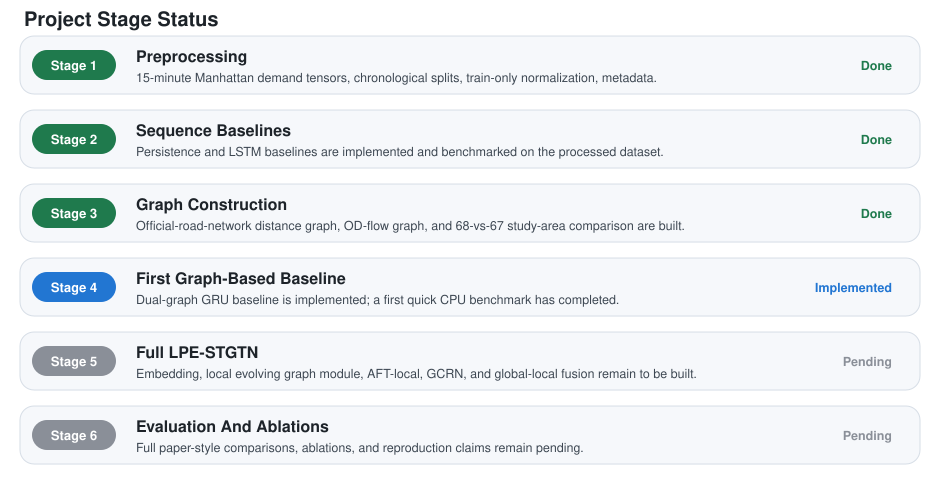

In [3]:
stage_rows = [
    {
        "stage": "Stage 1",
        "title": "Preprocessing",
        "summary": "15-minute Manhattan demand tensors, chronological splits, train-only normalization, metadata.",
        "status_key": "done",
        "status_label": "Done",
    },
    {
        "stage": "Stage 2",
        "title": "Sequence Baselines",
        "summary": "Persistence and LSTM baselines are implemented and benchmarked on the processed dataset.",
        "status_key": "done",
        "status_label": "Done",
    },
    {
        "stage": "Stage 3",
        "title": "Graph Construction",
        "summary": "Official-road-network distance graph, OD-flow graph, and 68-vs-67 study-area comparison are built.",
        "status_key": "done",
        "status_label": "Done",
    },
    {
        "stage": "Stage 4",
        "title": "First Graph-Based Baseline",
        "summary": "Dual-graph GRU baseline is implemented; a first quick CPU benchmark has completed.",
        "status_key": "implemented",
        "status_label": "Implemented",
    },
    {
        "stage": "Stage 5",
        "title": "Full LPE-STGTN",
        "summary": "Embedding, local evolving graph module, AFT-local, GCRN, and global-local fusion remain to be built.",
        "status_key": "pending",
        "status_label": "Pending",
    },
    {
        "stage": "Stage 6",
        "title": "Evaluation And Ablations",
        "summary": "Full paper-style comparisons, ablations, and reproduction claims remain pending.",
        "status_key": "pending",
        "status_label": "Pending",
    },
]

stage_frame = pd.DataFrame(stage_rows)[["stage", "title", "status_label", "summary"]]
display(html_table(stage_frame))
display(stage_status_svg(stage_rows))

## 2. Stage 1 And Stage 3: Dataset And Graph Track Comparison

The most important structural decision so far is the difference between the two active Manhattan study-area tracks:

- `68-zone mainline`: excludes `103` only, preserving the paper-reported zone count
- `67-zone sensitivity`: excludes both `103` and `104`, producing a cleaner road-network graph

The charts below are careful about units:

- pickup totals are shown in **pickup counts (rides)**
- road-network snap distances are shown in **feet**
- graph distance parameters are in **feet**, because the graph build uses projected `EPSG:2263` coordinates

In [7]:
tracks_frame = pd.DataFrame(
    [
        {
            "track": "68-zone mainline",
            "included_zones_count": int(mainline_metadata["num_zones"]),
            "excluded_location_ids": str(mainline_metadata["study_area_summary"]["excluded_location_ids"]),
            "total_pickups_2018": int(mainline_metadata["total_pickups"]),
            "distance_sigma_ft": float(mainline_graph_metadata["distance_graph"]["sigma"]),
            "max_road_distance_ft": float(mainline_graph_metadata["distance_graph"]["max_distance"]),
            "max_snap_distance_ft": float(mainline_snaps["snap_distance"].max()),
            "max_snap_distance_miles": miles_from_feet(float(mainline_snaps["snap_distance"].max())),
        },
        {
            "track": "67-zone sensitivity",
            "included_zones_count": int(sensitivity_metadata["num_zones"]),
            "excluded_location_ids": str(sensitivity_metadata["study_area_summary"]["excluded_location_ids"]),
            "total_pickups_2018": int(sensitivity_metadata["total_pickups"]),
            "distance_sigma_ft": float(sensitivity_graph_metadata["distance_graph"]["sigma"]),
            "max_road_distance_ft": float(sensitivity_graph_metadata["distance_graph"]["max_distance"]),
            "max_snap_distance_ft": float(sensitivity_snaps["snap_distance"].max()),
            "max_snap_distance_miles": miles_from_feet(float(sensitivity_snaps["snap_distance"].max())),
        },
    ]
)


## 3. Stage 2 And Stage 4: Baseline Benchmark Snapshot

The next view compares the available model benchmarks.

Important metric note:

- MAE and RMSE are shown in **pickup counts**, averaged over all forecasted zone-time cells
- because the target is a 15-minute pickup-count tensor, these can be read as **pickup-count error per zone per 15-minute forecast cell**
- MAPE is not emphasized in the charts because it is unstable with very small or zero demand values

benchmark,test_MAE_pickups_per_zone_15min_cell,test_RMSE_pickups_per_zone_15min_cell,validation_MAE_pickups_per_zone_15min_cell,training_epochs_completed
68-zone mainline / persistence,12.563956,23.411007,12.287365,0
68-zone mainline / LSTM,6.654453,12.291936,6.064351,10
67-zone sensitivity / persistence,12.751478,23.585068,12.470758,0
67-zone sensitivity / LSTM,6.560578,11.924477,6.122137,10
67-zone sensitivity / dual-graph GRU (quick CPU),18.281325,31.913867,17.496307,2


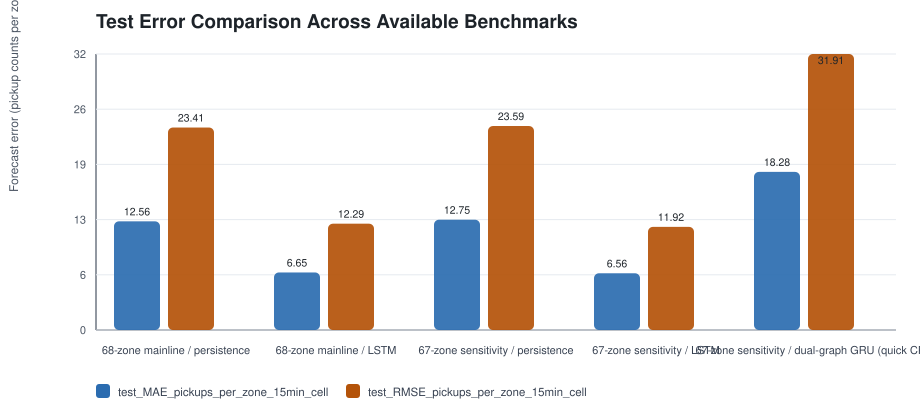

In [5]:
benchmark_rows = []
for label, report in baseline_reports.items():
    benchmark_rows.append(
        {
            "benchmark": label,
            "test_MAE_pickups_per_zone_15min_cell": float(report["metrics"]["test"]["mae"]),
            "test_RMSE_pickups_per_zone_15min_cell": float(report["metrics"]["test"]["rmse"]),
            "validation_MAE_pickups_per_zone_15min_cell": float(report["metrics"]["validation"]["mae"]),
            "training_epochs_completed": len(report.get("training_history", [])),
        }
    )
benchmark_frame = pd.DataFrame(benchmark_rows)

display(html_table(benchmark_frame))

benchmark_colors = ["#6b7280", "#1f7a4d"]
metric_chart_frame = benchmark_frame[[
    "benchmark",
    "test_MAE_pickups_per_zone_15min_cell",
    "test_RMSE_pickups_per_zone_15min_cell",
]]

display(
    grouped_bar_svg(
        metric_chart_frame,
        category_col="benchmark",
        value_cols=[
            "test_MAE_pickups_per_zone_15min_cell",
            "test_RMSE_pickups_per_zone_15min_cell",
        ],
        title="Test Error Comparison Across Available Benchmarks",
        y_label="Forecast error (pickup counts per zone per 15-minute forecast cell)",
        colors=["#2b6cb0", "#b45309"],
        value_formatter=lambda value: f"{value:.2f}",
    )
)

best_test_row = benchmark_frame.sort_values("test_MAE_pickups_per_zone_15min_cell").iloc[0]
display(
    HTML(
        "<p><strong>Current best completed benchmark:</strong> "
        f"{best_test_row['benchmark']} with test MAE {best_test_row['test_MAE_pickups_per_zone_15min_cell']:.3f} "
        "pickup counts per zone per 15-minute forecast cell.</p>"
    )
)

## 4. Project Interpretation And Next Stages

The current situation is easier to understand if we separate **infrastructure maturity** from **model maturity**:

- infrastructure maturity is strong through stage 4
- model maturity is still early, because the first graph-based benchmark is only a quick CPU run and the full LPE-STGTN is not implemented yet

In [6]:
summary_points = [
    f"Stages 1 to 3 are operational and validated. Stage 4 is implemented and has completed a first real graph-based run.",
    f"The 67-zone sensitivity track removes only {abs(int(track_comparison['total_pickups_delta']))} pickup from the full 2018 total while reducing the worst snap outlier from {track_comparison['primary']['max_snap_distance']:.0f} ft to {track_comparison['secondary']['max_snap_distance']:.0f} ft.",
    f"The current best predictive result is the 67-zone LSTM baseline with test MAE {baseline_reports['67-zone sensitivity / LSTM']['metrics']['test']['mae']:.3f} and test RMSE {baseline_reports['67-zone sensitivity / LSTM']['metrics']['test']['rmse']:.3f} pickup counts per zone per 15-minute forecast cell.",
    f"The first completed graph baseline is the 67-zone dual-graph GRU quick CPU run. It validates the stage-4 pipeline, but it is not yet competitive enough to replace the LSTM baseline.",
    "The next major engineering stage is stage 5: implement the full LPE-STGTN architecture, especially the local evolving-graph module, AFT-local, GCRN, and global-local fusion path.",
]

display(
    HTML(
        "<ul>" + "".join(f"<li>{point}</li>" for point in summary_points) + "</ul>"
    )
)

next_stage_frame = pd.DataFrame(
    [
        {
            "next_stage": "Stage 5",
            "objective": "Implement the full LPE-STGTN architecture",
            "why_it_matters": "This is the first stage that tests the paper's local dynamic module rather than only the global graph infrastructure.",
        },
        {
            "next_stage": "Stage 6",
            "objective": "Run controlled evaluation and ablations",
            "why_it_matters": "Only then can the repo make defensible claims about reproduction quality and component value.",
        },
    ]
)
display(html_table(next_stage_frame))

next_stage,objective,why_it_matters
Stage 5,Implement the full LPE-STGTN architecture,This is the first stage that tests the paper's local dynamic module rather than only the global graph infrastructure.
Stage 6,Run controlled evaluation and ablations,Only then can the repo make defensible claims about reproduction quality and component value.
